In [1]:
import psi4
import numpy as np
from cqed_rhf.calculator import CQEDRHFCalculator
# ─────────────────────────────────────────────
# Psi4 basic config
# ─────────────────────────────────────────────
psi4.set_memory("10 GB")
psi4.set_num_threads(2)
psi4.set_output_file("psi4_env_check.out", False)
psi4.core.clean()
psi4.core.clean_options()



  Memory set to   9.313 GiB by Python driver.
  Threads set to 2 by Python driver.


In [6]:
# Distances along z-axis for Br
br_distances = np.linspace(-1.5, -2.5, 20)  # 20 points between 1.4 and 4.0 Å
energies = []

#br_distances = [4.0]
# Geometry of nitrobenzene without Br
base_geom = """
1 1
C                  0.51932475    1.23303451   -0.03194925
C                  1.94454413    1.26916358   -0.03672882
C                  2.62037793    0.09283428   -0.02499003
C                 -0.19603352    0.03013062    0.00102732
H                 -0.02069420    2.17423764   -0.04336646
H                  2.48281698    2.20891057   -0.03611879
H                 -1.27770137    0.03990295    0.01166953
N                  4.09213475    0.09594076    0.03662979
O                  4.63930696   -1.02169275    0.14459220
O                  4.66489883    1.19839699   -0.02327545
C                  0.49428518   -1.16712649    0.02099746
H                 -0.03251071   -2.11492669    0.05447935
C                  1.96291176   -1.21653219   -0.02111314
H                  2.44359113   -1.96306433    0.61513886
"""

psi4_options = {"basis": "6-311G*",
                  "reference": "rks",
                  "scf_type": "df",
                  "e_convergence": 1e-9,
                  "d_convergence":1e-9,
                  "dft_radial_points": 99,
                  "dft_spherical_points": 590,
                  "dft_pruning_scheme": "none"
}
    
# Psi4 options
psi4.set_options(psi4_options)


lambda_vector = np.array([0.078, 0.055, 0.027])
omega = 0.06615



calc = CQEDRHFCalculator(
    lambda_vector=lambda_vector,
    psi4_options=psi4_options,
    omega=0.06615,
    charge=1,
    multiplicity=1,
    density_fitting=True,
    functional="wb97x-d",
    debug=False,
)


for z in br_distances:
    geom_str = base_geom + f"Br 2.17304025   -1.94912156  {z:.3f}\nunits angstrom\nno_com\nno_reorient\nsymmetry c1"
    mol = psi4.geometry(geom_str)
    E = calc.energy(geom_str)
    energies.append(E)
    print(f"Distance {z:.2f} Å: Energy = {E:.8f} Hartree")

# UKS results
#Distance 2.00 Å: Energy = -3010.34004850 Hartree
#Distance 2.50 Å: Energy = -3010.41880905 Hartree
#Distance 3.00 Å: Energy = -3010.42316702 Hartree
#Distance 3.50 Å: Energy = -3010.41105499 Hartree




Running CQED-SCF energy calculation...

Functional: wb97x
Starting CQED-SCF calculation...
Method: RKS
Functional: wb97x
Using density fitting through Psi4 JK.
Dispersion correction energy: 0.004084364911 Eh
Total energy (CQED + dispersion): -3010.263054029109 Eh
Distance -1.50 Å: Energy = -3010.26305403 Hartree

Running CQED-SCF energy calculation...

Functional: wb97x
Starting CQED-SCF calculation...
Method: RKS
Functional: wb97x
Using density fitting through Psi4 JK.
Dispersion correction energy: 0.003952214293 Eh
Total energy (CQED + dispersion): -3010.281250765235 Eh
Distance -1.55 Å: Energy = -3010.28125077 Hartree

Running CQED-SCF energy calculation...

Functional: wb97x
Starting CQED-SCF calculation...
Method: RKS
Functional: wb97x
Using density fitting through Psi4 JK.
Dispersion correction energy: 0.003778664275 Eh
Total energy (CQED + dispersion): -3010.294745747661 Eh
Distance -1.61 Å: Energy = -3010.29474575 Hartree

Running CQED-SCF energy calculation...

Functional: wb

In [7]:
#br_distances = np.linspace(2.0, 4.0, 5)  # 20 points between 1.4 and 4.0 Å

# 2️⃣ Find minimum distance from the scan
min_index_s = np.argmin(energies)
min_distance = br_distances[min_index_s]
print(f"\nApproximate minimum for RKS singlates at z = {min_distance:.2f} with energy {energies[min_index_s]:.8f} Hartree")

#min_index_s_uks = np.argmin(energies_sing_uks)
#min_distance_s_uks = br_distances[min_index_s_uks]
#print(f"\nApproximate minimum for UKS singlates at z = {min_distance_s_uks:.2f} with energy {energies[min_index_s_uks]:.8f} Hartree")

#min_index_t = np.argmin(energies_triplet)
#min_distance_t = br_distances[min_index_t]
#print(f"\nApproximate minimum for triplates at z = {min_distance_t:.2f} with energy {energies_triplet[min_index_t]:.8f} Hartree")



# 3️⃣ Single-point calculation at 6-311G* at the minimum
#psi4.set_options({"basis": "6-311G*",
#                  "reference": "uhf",
#                  "scf_type": "df",
#                  "e_convergence": 1e-6})

# min_geom = base_geom + f"Br 0.000000 0.000000 {min_distance:.3f}\nunits angstrom\nsymmetry c1"
# min_mol = psi4.geometry(min_geom)
# e_6311G = psi4.energy("b3lyp", molecule=min_mol)
# print(f"\nSingle-point energy at minimum with 6-311G* for = {e_6311G:.8f} Hartree")




Approximate minimum for RKS singlates at z = -1.87 with energy -3010.31870854 Hartree


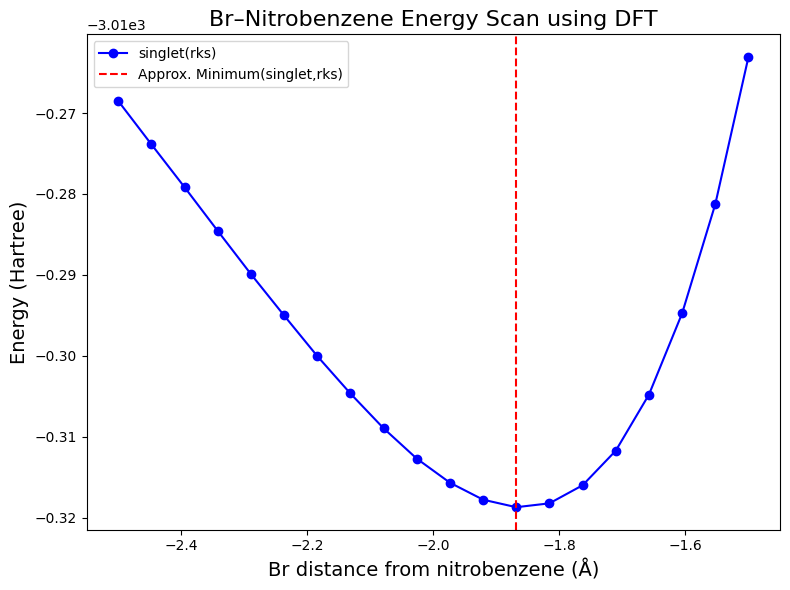

In [8]:
import matplotlib.pyplot as plt
# 4️⃣ Plot scan
plt.figure(figsize=(8,6))
plt.plot(br_distances, energies, marker='o', linestyle='-', color='b', label='singlet(rks)')
#plt.plot(br_distances, energies_sing_uks, marker='s', linestyle='--', color='g', label='singlet(uks)')
plt.axvline(min_distance, color='r', linestyle='--', label='Approx. Minimum(singlet,rks)')
#plt.axvline(min_distance_s_uks, color='m', linestyle='--', label='Approx. Minimum (singlet,uks)')
plt.xlabel("Br distance from nitrobenzene (Å)", fontsize=14)
plt.ylabel("Energy (Hartree)", fontsize=14)
plt.title("Br–Nitrobenzene Energy Scan using DFT", fontsize=16)
#plt.savefig("/Users/rmandern/code/md-cqed/br_nitrobenzene_wb97xd_uks.png", dpi=300)
# plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(energies)